In [32]:
import yfinance as yf

In [33]:
!pip3 install numpy

In [34]:
import numpy as np

In [35]:
import sys

In [36]:
sp500 = yf.Ticker("^GSPC")

In [37]:
sp500 = sp500.history(period="max")

In [38]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2025-07-16 00:00:00-04:00', '2025-07-17 00:00:00-04:00',
               '2025-07-18 00:00:00-04:00', '2025-07-21 00:00:00-04:00',
               '2025-07-22 00:00:00-04:00', '2025-07-23 00:00:00-04:00',
               '2025-07-24 00:00:00-04:00', '2025-07-25 00:00:00-04:00',
               '2025-07-28 00:00:00-04:00', '2025-07-29 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24509, freq=None)

<Axes: xlabel='Date'>

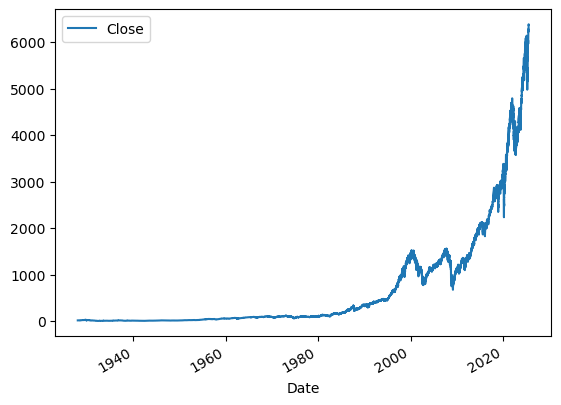

In [39]:
sp500.plot.line(y="Close", use_index=True)

In [40]:
del sp500["Dividends"]

In [41]:
del sp500["Stock Splits"]

In [42]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [43]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)
#target is "1" if tomorrow's price increased and "0" if it decreased

In [44]:
#removes all rows before Jan 1, 1990
sp500 = sp500.loc["1990-01-01":].copy()

In [45]:
!pip install --upgrade --force-reinstall numpy scipy scikit-learn

  Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached scipy-1.16.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached scikit_learn-1.7.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl (5.1 MB)
Using cached scipy-1.16.1-cp312-cp312-macosx_14_0_arm64.whl (20.9 MB)
Using cached scikit_learn-1.7.1-cp312-cp312-macosx_12_0_arm64.whl (8.6 MB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.2
    Uninstalling numpy-2.3.2:
      Successfully

In [46]:
import sklearn

In [47]:
from sklearn.ensemble import RandomForestClassifier
#Random forest are more resistent to overfitting

# Incerased n_esitmators improves accuracy up to a cetain point. 
# min_samples_split helps stop overfitting but decreases accuracy
model = RandomForestClassifier(n_estimators=200, min_samples_split=100, random_state=1)

train = sp500.iloc[:-100] #all the rows except the last 100
test = sp500.iloc[-100:] #only the last 100 rows

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
RandomForestClassifier(min_samples_split=100, random_state=1)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
from sklearn.metrics import precision_score
# How accurate was the model when predicting "Target" if it will go up (percent)

preds = model.predict(test[predictors])

In [50]:
import pandas as pd

In [51]:
preds = pd.Series(preds, index=test.index)

In [52]:
precision_score(test["Target"], preds)

0.581081081081081

In [53]:
combined = pd.concat([test["Target"], preds], axis=1)

<Axes: xlabel='Date'>

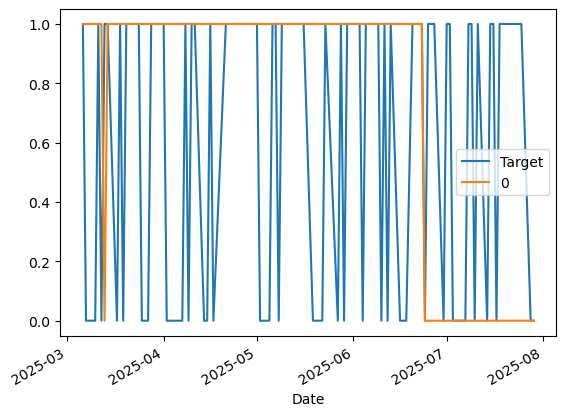

In [54]:
combined.plot()

In [55]:

def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"]) #fit model using training and target
    preds = model.predict(test[predictors]) #generates predictions
    preds = pd.Series(preds, index=test.index, name = "Predictions") #puts model into a series
    combined = pd.concat([test["Target"], preds], axis=1) #combines everything together
    return combined

In [56]:
def backtest(data, model, predictors, start=2500, step=250): #start=2500 means train the first model with 10 years of data
    all_predictions = []
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [57]:
predictions = backtest(sp500, model, predictors)

In [58]:
predictions["Predictions"].value_counts()

Predictions
0    3727
1    2732
Name: count, dtype: int64

In [59]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5281844802342606

In [60]:
predictions["Target"].value_counts() / predictions.shape[0] #this is the actual percentange of if it went up or down


Target
1    0.536925
0    0.463075
Name: count, dtype: float64

In [61]:
horizons = [2,5,60,250,1000] #calc mean close price in the last 2 days, 5 days, 3 months, etc...
new_predictors = []

for horizon in horizons:
    rolling_average = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500 ["Close"] / rolling_average["Close"]

    trend_column =f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

    new_predictors += [ratio_column, trend_column]

In [62]:
sp500 = sp500.dropna()

In [63]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-22 00:00:00-04:00,6306.600098,6316.120117,6281.709961,6309.620117,5662040000,6358.910156,1,1.000319,2.0,1.002384,4.0,1.055234,38.0,1.086153,142.0,1.322856,530.0
2025-07-23 00:00:00-04:00,6326.899902,6360.640137,6317.490234,6358.910156,5642510000,6363.350098,1,1.003891,2.0,1.007168,4.0,1.061012,38.0,1.094033,143.0,1.332643,531.0
2025-07-24 00:00:00-04:00,6368.600098,6381.310059,6360.569824,6363.350098,5282720000,6388.640137,1,1.000349,2.0,1.005768,4.0,1.059294,38.0,1.094092,144.0,1.333030,531.0


In [64]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [65]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"]) #fit model using training and target
    preds = model.predict_proba(test[predictors])[:,1] #gives the probability of the stock going up
    preds[preds >= .6] = 1
    preds[preds < .6] = 0
    preds = pd.Series(preds, index=test.index, name = "Predictions") #puts model into a series
    combined = pd.concat([test["Target"], preds], axis=1) #combines everything together
    return combined

In [66]:
predictions = backtest(sp500, model, new_predictors)

In [67]:
predictions["Predictions"].value_counts()

Predictions
0.0    4589
1.0     869
Name: count, dtype: int64

In [68]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5742232451093211

In [69]:
#now I want to train the model on CPI, PPI, Unemployment, GDP, and the fed interest rates.

In [70]:
!pip install fredapi

In [71]:
%pip install --upgrade --force-reinstall numpy pandas

  Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pandas-2.3.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl (5.1 MB)
Using cached pandas-2.3.1-cp312-cp312-macosx_11_0_arm64.whl (10.7 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found e

In [72]:
from fredapi import Fred

In [73]:
fred = Fred(api_key='1589088aac5d668a6d59c92eb458255e')

In [74]:
cpi = fred.get_series('CPIAUCSL')           # Consumer Price Index
ppi = fred.get_series('PPIACO')             # Producer Price Index
unemployment = fred.get_series('UNRATE')    # Unemployment rate
gdp = fred.get_series('A191RL1Q225SBEA')     # Real GDP Growth (percent change)
interest_rate = fred.get_series('FEDFUNDS') # Federal Funds Rate

In [75]:
#cutting off all dates before 1993-12-01
cpi = cpi.loc["1993-12-01":].copy()
ppi = ppi.loc["1993-12-01":].copy()
unemployment = unemployment.loc["1993-12-01":].copy()
gdp = gdp.loc["1993-12-01":].copy()
interest_rate = interest_rate.loc["1993-12-01":].copy()

In [76]:
cpi = cpi.resample('D').ffill()  # Forward-fill cpi data to each day
ppi = ppi.resample('D').ffill()  # Forward-fill ppi data to each day
unemployment = unemployment.resample('D').ffill()  # Forward-fill unemployment data to each day
interest_rate = interest_rate.resample('D').ffill()  # Forward-fill interest rate data to each day
gdp = gdp.resample('D').ffill()  # Forward-fill gdp data to each day

In [77]:
cpi.index

DatetimeIndex(['1993-12-01', '1993-12-02', '1993-12-03', '1993-12-04',
               '1993-12-05', '1993-12-06', '1993-12-07', '1993-12-08',
               '1993-12-09', '1993-12-10',
               ...
               '2025-05-23', '2025-05-24', '2025-05-25', '2025-05-26',
               '2025-05-27', '2025-05-28', '2025-05-29', '2025-05-30',
               '2025-05-31', '2025-06-01'],
              dtype='datetime64[ns]', length=11506, freq='D')

In [78]:
sp500.index

DatetimeIndex(['1993-12-14 00:00:00-05:00', '1993-12-15 00:00:00-05:00',
               '1993-12-16 00:00:00-05:00', '1993-12-17 00:00:00-05:00',
               '1993-12-20 00:00:00-05:00', '1993-12-21 00:00:00-05:00',
               '1993-12-22 00:00:00-05:00', '1993-12-23 00:00:00-05:00',
               '1993-12-27 00:00:00-05:00', '1993-12-28 00:00:00-05:00',
               ...
               '2025-07-15 00:00:00-04:00', '2025-07-16 00:00:00-04:00',
               '2025-07-17 00:00:00-04:00', '2025-07-18 00:00:00-04:00',
               '2025-07-21 00:00:00-04:00', '2025-07-22 00:00:00-04:00',
               '2025-07-23 00:00:00-04:00', '2025-07-24 00:00:00-04:00',
               '2025-07-25 00:00:00-04:00', '2025-07-28 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=7958, freq=None)